# AGFN denovo: molecule + docking visualization

Three views of what the model is generating:

1. **Trajectory step grids** — partial molecules at each GFN action step (RDKit 2D).
2. **Top-K across training** — best generated molecules ranked by reward or Vina affinity, from `<log_dir>/top_k_mols.pt` produced by the `TopKTracker` hook in `samp_iter_finetune.py`.
3. **3D docked pose** — a fresh batch redocked into a persistent directory, rendered with py3Dmol.

**Run from the repo root.** All paths in `denovo.yml` are relative; cell 2 cd's to the repo root for you. Requires `py3Dmol` (in `requirements_jn.txt`).

In [1]:
# ----- User parameters (edit these) -----
CONFIG_PATH      = "./src/config/denovo.yml"
SAVED_MODEL_PATH = None     # None -> use hps.saved_model_path from YAML
TARGET_NAME      = None     # None -> use hps.target_name from YAML
N_SAMPLES        = 8        # trajectories to draw
N_DOCK           = 4        # subset to dock
TOP_K_SHOW       = 20       # rows of top-K to render (max 100)
TOP_K_RANK_BY    = "reward" # "reward" or "affinity"
PERSIST_DIR      = "./AGFN_logs/visualize_out"
DEVICE_ID        = 0
SEED             = 0

In [2]:
import os, sys, json, yaml
from pathlib import Path

# chdir to repo root so relative paths in denovo.yml resolve as they do for denovo_driver.py
_here = Path.cwd()
for cand in [_here, *_here.parents]:
    if (cand / "src" / "config" / "denovo.yml").exists():
        os.chdir(cand); break
REPO_ROOT = Path.cwd()
print("repo root:", REPO_ROOT)

for p in ("src", "src/apps/docking", "src/apps/docking/denovo"):
    full = str((REPO_ROOT / p).resolve())
    if full not in sys.path: sys.path.insert(0, full)

import numpy as np
import torch
from easydict import EasyDict
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import IPythonConsole
import py3Dmol
RDLogger.DisableLog("rdApp.*")
torch.manual_seed(SEED); np.random.seed(SEED)

repo root: /home/aid/dkoh/third_party/AGFN


In [3]:
# Load + patch hps, then bootstrap tmp_config.json so importing gpuvina later doesn't crash.
with open(CONFIG_PATH) as f:
    hps = EasyDict(yaml.safe_load(f)).finetuning
hps.update({"Z_learning_rate": 1e-3})

if hps.task == "QedxSaxDock":
    conditional_range_dict = {
        "tpsa":      [[10, 200], [10, 200], 0],
        "num_rings": [[1, 5],   [1, 5],   1],
        "sas":       [[1, 5],   [1, 5],   0],
        "qed":       [[0.5, 1], [0, 1],   0],
    }
else:
    raise RuntimeError(f"unsupported task: {hps.task}")
cond_prop_var = {"tpsa": 20, "num_rings": 1, "sas": 1, "qed": 1}
hps.task_conditionals = False
hps.task_rewards_only = False
hps.update(conditional_range_dict)

if SAVED_MODEL_PATH is not None: hps.saved_model_path = SAVED_MODEL_PATH
if TARGET_NAME      is not None: hps.target_name      = TARGET_NAME

gfn_samples_path = f"{hps.gfn_samples_path}/GFN_gen_samples_{hps.target_name}/"
os.makedirs(gfn_samples_path, exist_ok=True)
os.makedirs(PERSIST_DIR, exist_ok=True)

# normally written by RewardDockFineTune.__init__; we do it standalone since
# gpuvina.py reads ./data/docking/tmp_config.json at module import time.
os.makedirs("./data/docking", exist_ok=True)
with open("./data/docking/tmp_config.json", "w") as f:
    json.dump(hps.target_grid, f, indent=4)

print("target_name:     ", hps.target_name)
print("saved_model_path:", hps.saved_model_path)
print("log_dir:         ", hps.log_dir)
print("gfn_samples_path:", gfn_samples_path)

target_name:      braf
saved_model_path: ./saved_models/pretrained/decent-butterfly-1_110000.pt
log_dir:          ./AGFN_logs/debug_run
gfn_samples_path: ./data/gfn_samples/GFN_gen_samples_braf/


In [4]:
# Build DockingFineTuner and load checkpoint. Reuses the exact constructor
# used by training, so model architecture and checkpoint loading match.
from denovo_trainer import DockingFineTuner

finetuner = DockingFineTuner(
    hps, conditional_range_dict, cond_prop_var,
    hps.saved_model_path,
    rank=DEVICE_ID, world_size=1,
    gfn_samples_path=gfn_samples_path,
)
finetuner.gfn_trainer.model.train(False)  # PyTorch evaluation mode
finetuner.gfn_trainer.model_prior.train(False)
print("device:", finetuner.device)

molbuildingenv.py c import error
len loaded dict: 507
finetuner start step 110000
device: cuda:0


In [5]:
# Sample N_SAMPLES trajectories. Mirrors samp_iter_finetune.py:217-224.
ci = finetuner.cond_info_task
cond_info     = ci.compute_cond_info_forward(N_SAMPLES)
cond_info_enc = ci.thermometer_encoding(cond_info).to(finetuner.device)
with torch.no_grad():
    trajs = finetuner.graph_sampler.sample_from_model(
        finetuner.gfn_trainer.model, N_SAMPLES,
        cond_info_enc, finetuner.device,
        random_stop_action_prob=0.0,
        random_action_prob=0.0,
        seed_graph=None,
    )
valid = [t for t in trajs if t["is_valid"]]
print(f"sampled {len(trajs)} trajectories, {len(valid)} valid")

sampled 8 trajectories, 8 valid


trajectory 0  steps=40


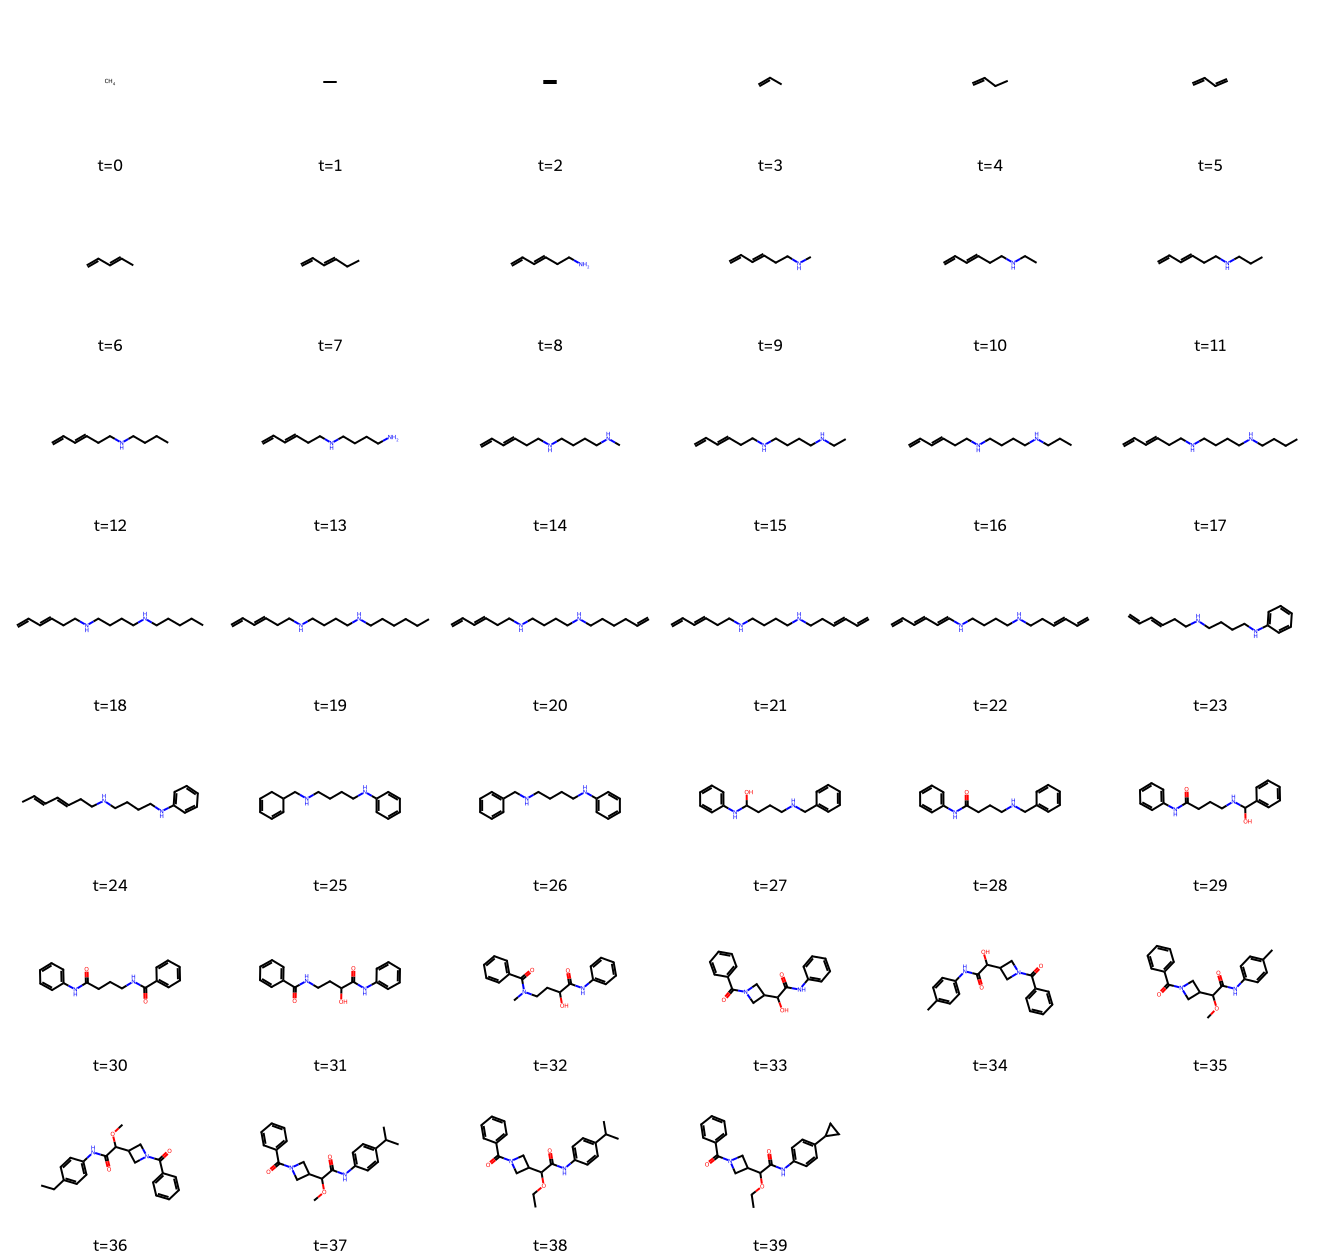

trajectory 1  steps=40


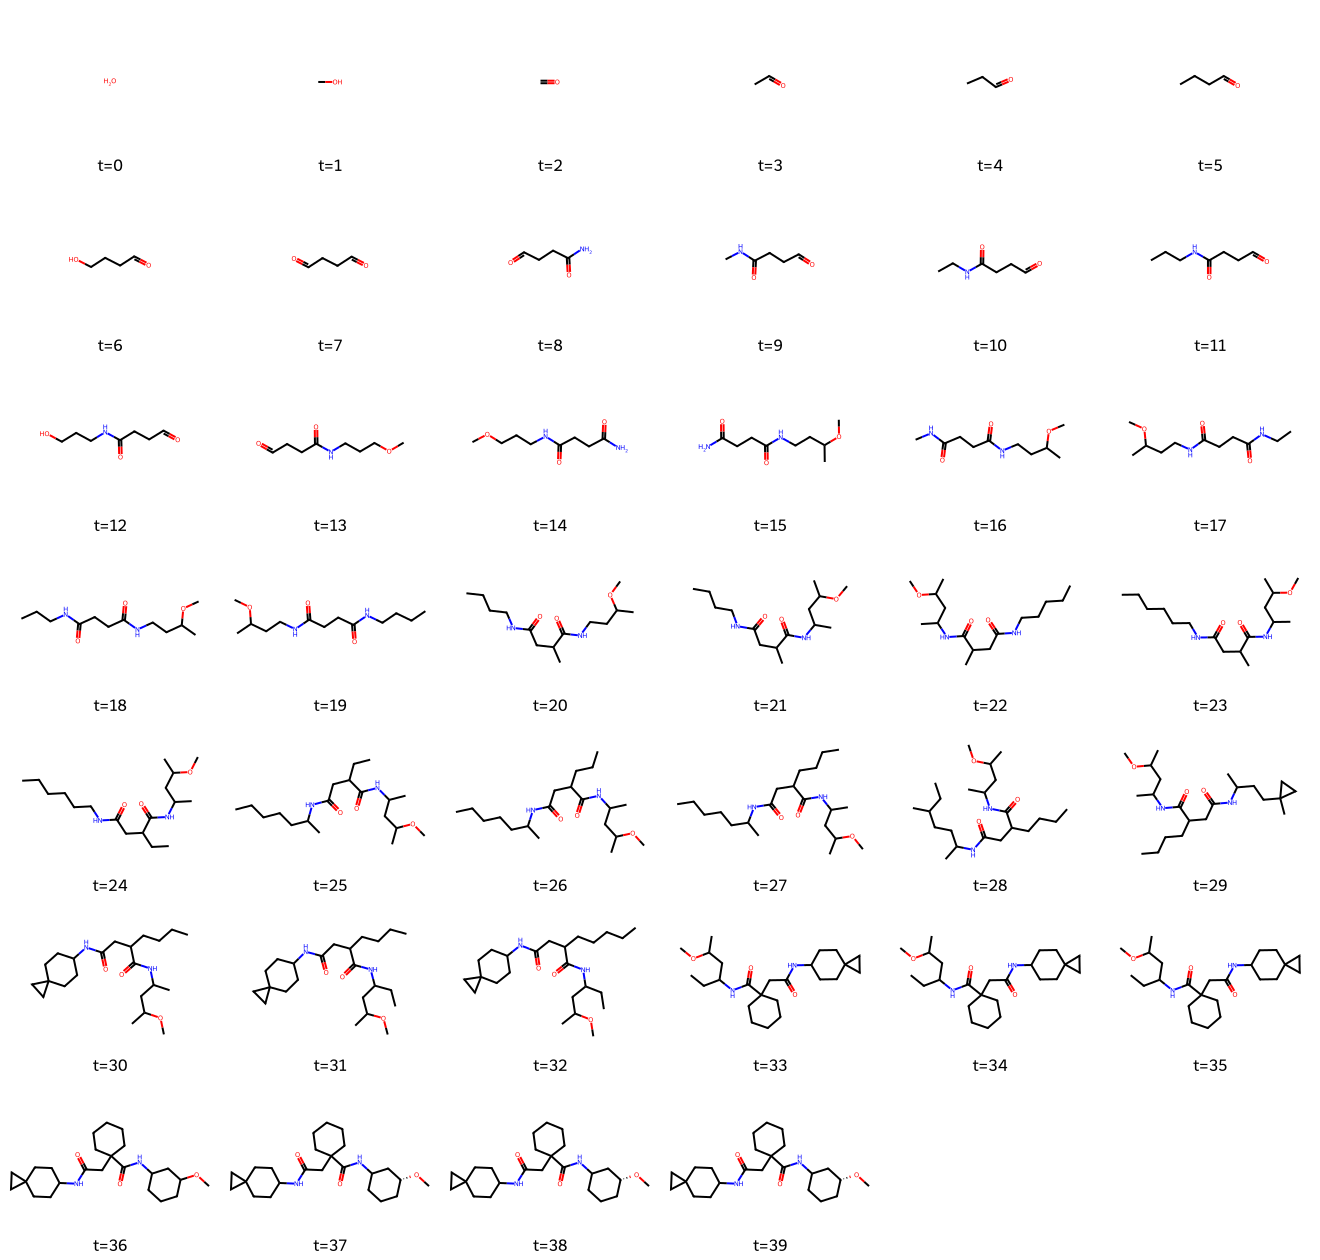

trajectory 2  steps=40


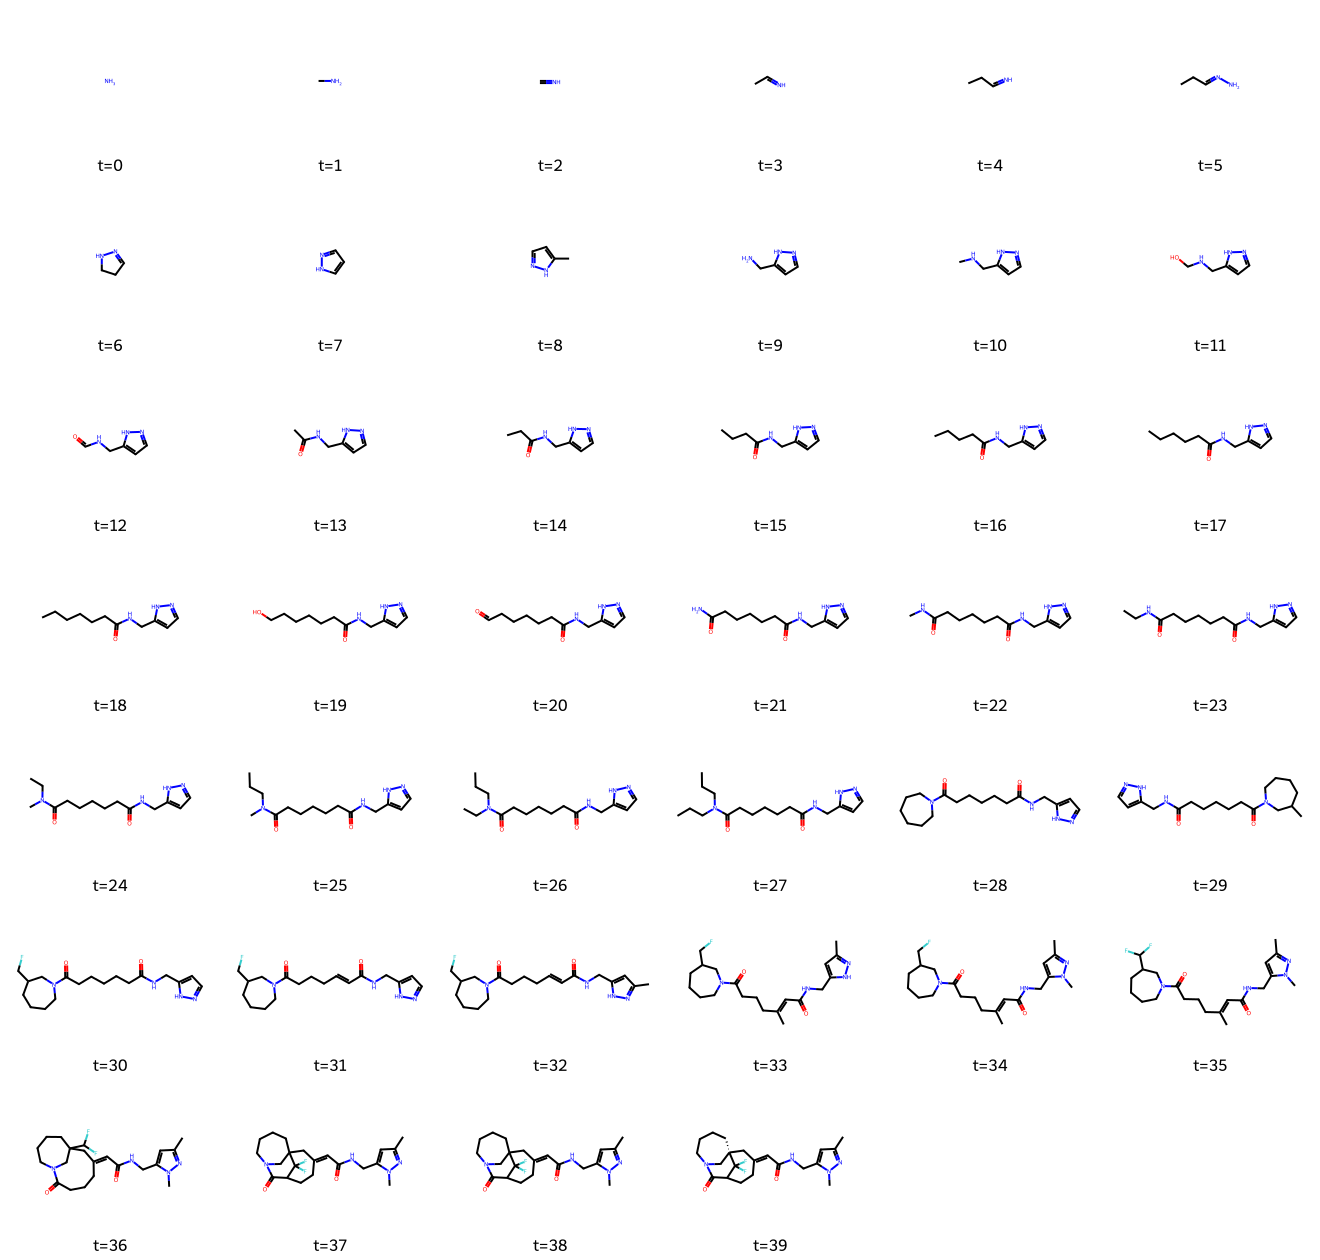

In [6]:
# Trajectory step grids. traj[t][0] is already the pre-action Graph state —
# no need to call env.step to reconstruct intermediates.
from IPython.display import display

for idx, t in enumerate(valid[:3]):
    steps = []
    for g, _action in t["traj"]:
        if len(g.nodes) == 0:
            continue
        try:
            m = finetuner.ctx.graph_to_mol(g)
        except Exception:
            m = None
        if m is not None:
            steps.append(m)
    if not steps:
        print(f"trajectory {idx}: no renderable intermediate graphs")
        continue
    print(f"trajectory {idx}  steps={len(steps)}")
    legends = [f"t={i}" for i in range(len(steps))]
    display(Draw.MolsToGridImage(steps, molsPerRow=6, subImgSize=(220, 180), legends=legends))

showing top 20 of 100 ranked by reward


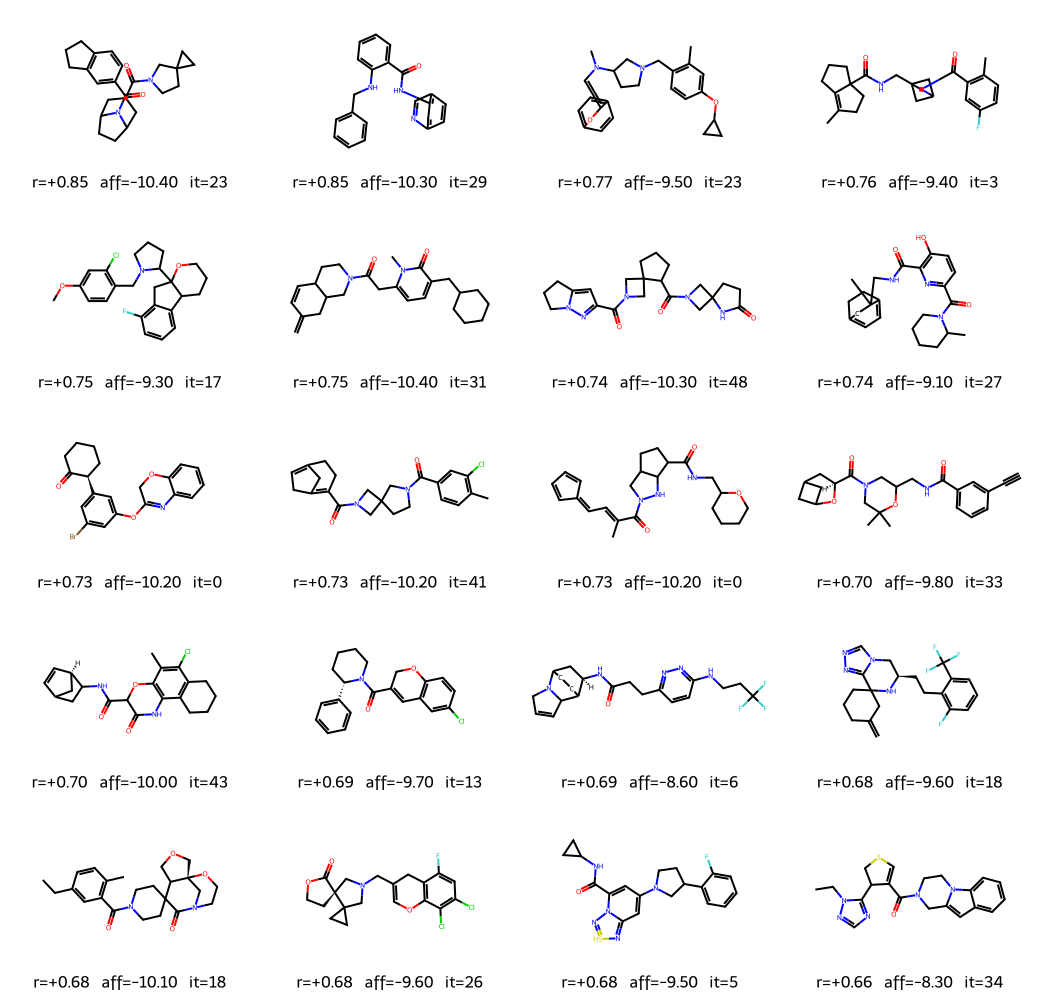

In [7]:
# Top-K best generated molecules across the whole training run.
# Produced by TopKTracker hook in src/iterators/samp_iter_finetune.py.
top_path = Path(hps.log_dir) / "top_k_mols.pt"
if not top_path.exists():
    print(f"WARNING: no top-K dump at {top_path}.")
    print("Re-run training (denovo_driver.py) so the TopKTracker hook can write it.")
    print("Saves trigger every hps.checkpoint_every iters; defaults to 10.")
else:
    top = torch.load(top_path, map_location="cpu")
    bucket_key = f"top_by_{TOP_K_RANK_BY}"
    available_ks = sorted(top.get(bucket_key, {}).keys())
    if not available_ks:
        print(f"top_k_mols.pt has no bucket '{bucket_key}'")
    else:
        k = max(k for k in available_ks if k <= max(available_ks))
        bucket = top[bucket_key][k]
        n_show = min(TOP_K_SHOW, len(bucket))
        rows = bucket[:n_show]
        mols, legends = [], []
        for smiles, reward, affinity, iteration in rows:
            m = Chem.MolFromSmiles(smiles)
            if m is None: continue
            aff_str = "  n/a" if affinity is None else f"{affinity:+.2f}"
            mols.append(m)
            legends.append(f"r={reward:+.2f}  aff={aff_str}  it={iteration}")
        print(f"showing top {len(mols)} of {len(bucket)} ranked by {TOP_K_RANK_BY}")
        display(Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(260, 200), legends=legends))

In [8]:
# Extract final SMILES from the live sample for re-docking.
smiles, final_mols = [], []
for t in valid[:N_DOCK]:
    try:
        m = finetuner.ctx.graph_to_mol(t["traj"][-1][0])
        s = Chem.MolToSmiles(m) if m is not None else None
    except Exception:
        s, m = None, None
    if s:
        smiles.append(s); final_mols.append(m)
for i, s in enumerate(smiles):
    print(f"  [{i}] {s}")
print(f"will dock {len(smiles)} molecules")

  [0] CCOC(C(=O)Nc1ccc(C2CC2)cc1)C1CN(C(=O)c2ccccc2)C1
  [1] CO[C@@H]1CCCC(NC(=O)C2(CC(=O)NC3CCC4(CC3)CC4)CCCCC2)C1
  [2] Cc1cc(CNC(=O)C=C2CCC3C(=O)N4CCCC[C@@](C2)(C4)C3(F)F)n(C)n1
  [3] Cc1cccc2c1cc1n2C(=O)NC(=O)C2c3cccn3CCN2C1=O
will dock 4 molecules


In [9]:
# Dock the batch via QuickVina2GPU. Output .pdbqt files persist under PERSIST_DIR.
from gpuvina import QuickVina2GPU

vina_in = os.path.abspath(os.path.join(PERSIST_DIR, f"{hps.target_name}_lig_in"))
vina = QuickVina2GPU(
    vina_path=hps.vina_path,
    target=hps.target_name,
    input_dir=vina_in,
    save_confs=True, print_logs=False,
)
smiles_out, affinities, rewards = vina.calculate_rewards(smiles)
print("\nresults")
print(f"  out_dir: {vina.out_dir}")
for i, (s, a, r) in enumerate(zip(smiles_out, affinities, rewards)):
    print(f"  [{i}] aff={a:+.2f}  reward={float(r):+.3f}  smi={s}")

Smiles conformation calculation: 100%|███████████████████████████████████████████████████| 4/4 [00:00<00:00, 153.43it/s]


Dropped 2/4 ligands with non-AutoDock atom types
AFFINITIES: mean=-4.1, std=4.105, min=-8.5, max=0.0

results
  out_dir: /home/aid/dkoh/third_party/AGFN/AGFN_logs/visualize_out/braf_lig_in_out
  [0] aff=-7.90  reward=+0.627  smi=CCOC(C(=O)Nc1ccc(C2CC2)cc1)C1CN(C(=O)c2ccccc2)C1
  [1] aff=-8.50  reward=+0.682  smi=CO[C@@H]1CCCC(NC(=O)C2(CC(=O)NC3CCC4(CC3)CC4)CCCCC2)C1
  [2] aff=+0.00  reward=-0.091  smi=Cc1cc(CNC(=O)C=C2CCC3C(=O)N4CCCC[C@@](C2)(C4)C3(F)F)n(C)n1
  [3] aff=+0.00  reward=-0.091  smi=Cc1cccc2c1cc1n2C(=O)NC(=O)C2c3cccn3CCN2C1=O


In [10]:
# 3D pose viewer. Receptor rainbow cartoon + ligand green-carbon sticks.
def view_pose(receptor_pdbqt, ligand_pdbqt, w=500, h=400):
    with open(receptor_pdbqt) as f: rec = f.read()
    with open(ligand_pdbqt)   as f: lig = f.read()
    v = py3Dmol.view(width=w, height=h)
    v.addModel(rec, "pdbqt"); v.setStyle({"model": 0}, {"cartoon": {"color": "spectrum"}})
    v.addModel(lig, "pdbqt"); v.setStyle({"model": 1}, {"stick": {"colorscheme": "greenCarbon"}})
    v.zoomTo({"model": 1})
    return v

receptor = hps.target_grid[hps.target_name].receptor
pose_paths = []
for i in range(len(smiles_out)):
    pose = os.path.join(vina.out_dir, f"input_{i}_out.pdbqt")
    if not os.path.exists(pose):
        print(f"[{i}] no pose file (vina likely failed)"); pose_paths.append(None); continue
    pose_paths.append(pose)
    aff = affinities[i]
    print(f"\n[{i}]  aff={aff:+.2f}  smi={smiles_out[i]}")
    view_pose(receptor, pose).show()


[0]  aff=-7.90  smi=CCOC(C(=O)Nc1ccc(C2CC2)cc1)C1CN(C(=O)c2ccccc2)C1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


[1]  aff=-8.50  smi=CO[C@@H]1CCCC(NC(=O)C2(CC(=O)NC3CCC4(CC3)CC4)CCCCC2)C1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[2] no pose file (vina likely failed)
[3] no pose file (vina likely failed)


In [11]:
# Optional summary save (JSON, no binary objects). Trajectories regenerate from
# the same checkpoint + seed, so we don't persist them.
summary = {
    "target_name":       hps.target_name,
    "saved_model_path":  hps.saved_model_path,
    "smiles":            list(smiles_out),
    "affinities":        [float(a) for a in affinities],
    "rewards":           [float(r) for r in rewards],
    "pose_paths":        pose_paths,
    "receptor":          receptor,
}
out_path = os.path.join(PERSIST_DIR, f"{hps.target_name}_visualize_results.json")
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)
print("wrote", out_path)

wrote ./AGFN_logs/visualize_out/braf_visualize_results.json
